# PA006 — Camada 3: Uplift Modeling (T-Learner)

**Objetivo:** Estimar o efeito causal individual da campanha de retenção sobre cada cliente em risco de churn.

**Abordagem:** T-Learner com dois XGBoost independentes (um por grupo do A/B).  
**CATE:** `P(churn|controle) - P(churn|tratamento)` — positivo = campanha reduz churn.  
**Perfis:** Classificação em 4 grupos pelos eixos CATE × risco base (`p_control`).

**Inputs:**
- `data/processed/ab_pool_assignment.parquet` — 1.134 clientes (567 controle / 567 tratamento)
- `data/processed/X_churn.parquet` — 21 features comportamentais

**Output:** `data/processed/uplift_scores.parquet` — `customer_id | cate_score | perfil`

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) in ('notebooks', 'scripts'):
    os.chdir('..')

SEED = 42
np.random.seed(SEED)

AB_POOL_PATH = 'data/processed/ab_pool_assignment.parquet'
X_CHURN_PATH = 'data/processed/X_churn.parquet'
OUTPUT_PATH  = 'data/processed/uplift_scores.parquet'
FIGURES_PATH = 'reports/figures/'

TOP_K         = 200
CUSTO_CONTATO = 15
TICKET_MEDIO  = 350
DESCONTO      = 0.10
CATE_THRESHOLD   = 0.0
P_CONTROL_MEDIAN = None


## 1. Carregamento e join dos dados

In [2]:
ab_pool = pd.read_parquet(AB_POOL_PATH)
X_all   = pd.read_parquet(X_CHURN_PATH)

print(f'ab_pool : {ab_pool.shape}  | colunas: {ab_pool.columns.tolist()}')
print(f'X_all   : {X_all.shape}')
print()
print('Distribuicao de grupos:')
print(ab_pool['grupo'].value_counts().rename({0: 'Controle', 1: 'Tratamento'}))

ab_pool : (1134, 4)  | colunas: ['customer_id', 'churn_score', 'churn_real', 'grupo']
X_all   : (2758, 21)

Distribuicao de grupos:
grupo
tratamento    567
controle      567
Name: count, dtype: int64


In [3]:
# customer_id pode estar como coluna ou indice dependendo de como foi salvo
if 'customer_id' in ab_pool.columns:
    ab_pool = ab_pool.set_index('customer_id')

df = ab_pool.join(X_all, how='inner')

# Normaliza grupo para int (parquet pode salvar como string 'controle'/'tratamento')
if df['grupo'].dtype == object:
    df['grupo'] = df['grupo'].map({'controle': 0, 'tratamento': 1})

assert df.shape[0] == 1134, f'Shape inesperado: {df.shape[0]} linhas (esperado 1134)'
assert df.isnull().sum().sum() == 0, f'NaN encontrado apos join: {df.isnull().sum().sum()}'
assert set(df['grupo'].unique()) == {0, 1}, f'Valores inesperados em grupo: {df["grupo"].unique()}'

print(f'Dataset pos-join : {df.shape}')
print(f'NaN total        : {df.isnull().sum().sum()}')
print(f'Grupos (0=controle, 1=tratamento): {df["grupo"].value_counts().to_dict()}')

Dataset pos-join : (1134, 24)
NaN total        : 0
Grupos (0=controle, 1=tratamento): {1: 567, 0: 567}


## 2. Feature setup — verificação de leakage

In [4]:
LEAKAGE_COLS = ['churn_real', 'grupo', 'churn_score']
FEATURE_COLS = [c for c in X_all.columns if c not in LEAKAGE_COLS]
TARGET       = 'churn_real'

assert not any(c in FEATURE_COLS for c in LEAKAGE_COLS), 'Leakage detectado em FEATURE_COLS'

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Leakage removido : {LEAKAGE_COLS}')

Features (21): ['frequency', 'avg_ticket', 'gross_revenue', 'revenue_velocity', 'total_items', 'items_velocity', 'basket_size', 'unique_products', 'product_loyalty', 'avg_recency_days', 'return_value', 'return_orders', 'return_rate', 'return_value_ratio', 'customer_lifetime_days', 'log_gross_revenue', 'log_total_items', 'log_revenue_velocity', 'log_return_value', 'log_basket_size', 'log_items_velocity']
Leakage removido : ['churn_real', 'grupo', 'churn_score']


## 3. Split por grupo (treino/teste independentes)

O split é feito **dentro de cada grupo** — nunca mistura controle e tratamento antes do treino.

In [5]:
control   = df[df['grupo'] == 0]
treatment = df[df['grupo'] == 1]

X_c, y_c = control[FEATURE_COLS],   control[TARGET]
X_t, y_t = treatment[FEATURE_COLS], treatment[TARGET]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=SEED, stratify=y_c)
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=SEED, stratify=y_t)

print(f'Controle   | treino: {X_c_train.shape[0]} | teste: {X_c_test.shape[0]} | churn rate treino: {y_c_train.mean():.1%}')
print(f'Tratamento | treino: {X_t_train.shape[0]} | teste: {X_t_test.shape[0]} | churn rate treino: {y_t_train.mean():.1%}')


Controle   | treino: 453 | teste: 114 | churn rate treino: 44.4%
Tratamento | treino: 453 | teste: 114 | churn rate treino: 46.8%


## 4. T-Learner — Modelo de controle (Logistic Regression)


In [6]:
model_c = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=0.5,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=SEED,
    )),
])
model_c.fit(X_c_train, y_c_train)

auc_c_train = roc_auc_score(y_c_train, model_c.predict_proba(X_c_train)[:, 1])
auc_c_test  = roc_auc_score(y_c_test,  model_c.predict_proba(X_c_test)[:, 1])
print(f'Controle | AUC treino: {auc_c_train:.3f} | AUC teste: {auc_c_test:.3f} | gap: {auc_c_train - auc_c_test:.3f}')


Controle | AUC treino: 0.624 | AUC teste: 0.565 | gap: 0.059


## 5. T-Learner — Modelo de tratamento (Logistic Regression)


In [7]:
model_t = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=0.5,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=SEED,
    )),
])
model_t.fit(X_t_train, y_t_train)

auc_t_train = roc_auc_score(y_t_train, model_t.predict_proba(X_t_train)[:, 1])
auc_t_test  = roc_auc_score(y_t_test,  model_t.predict_proba(X_t_test)[:, 1])
print(f'Tratamento | AUC treino: {auc_t_train:.3f} | AUC teste: {auc_t_test:.3f} | gap: {auc_t_train - auc_t_test:.3f}')


Tratamento | AUC treino: 0.591 | AUC teste: 0.633 | gap: -0.041


## 6. CATE — Efeito causal individual

**CATE = P(churn|controle) - P(churn|tratamento)**  
Positivo: campanha reduz churn → potencialmente Persuadivel.  
Negativo: campanha aumenta risco → Sleeping Dog, evitar contato.

In [8]:
X_pool = df[FEATURE_COLS]

p_control   = model_c.predict_proba(X_pool)[:, 1]
p_treatment = model_t.predict_proba(X_pool)[:, 1]
cate        = p_control - p_treatment

df = df.copy()
df['cate_score']  = cate
df['p_control']   = p_control
df['p_treatment'] = p_treatment

test_idx = X_c_test.index.union(X_t_test.index)
df['is_test'] = df.index.isin(test_idx)

print(f'CATE media : {cate.mean():.4f}')
print(f'CATE std   : {cate.std():.4f}')
print(f'CATE min   : {cate.min():.4f} | max: {cate.max():.4f}')
print(f'CATE > 0   : {(cate > 0).sum()} ({(cate > 0).mean():.1%})')
print(f'CATE <= 0  : {(cate <= 0).sum()} ({(cate <= 0).mean():.1%})')
print(f'Clientes no conjunto de teste: {df["is_test"].sum()}')


CATE media : 0.0011
CATE std   : 0.1257
CATE min   : -0.9928 | max: 0.7044
CATE > 0   : 620 (54.7%)
CATE <= 0  : 514 (45.3%)
Clientes no conjunto de teste: 228


## 7. Distribuição do CATE

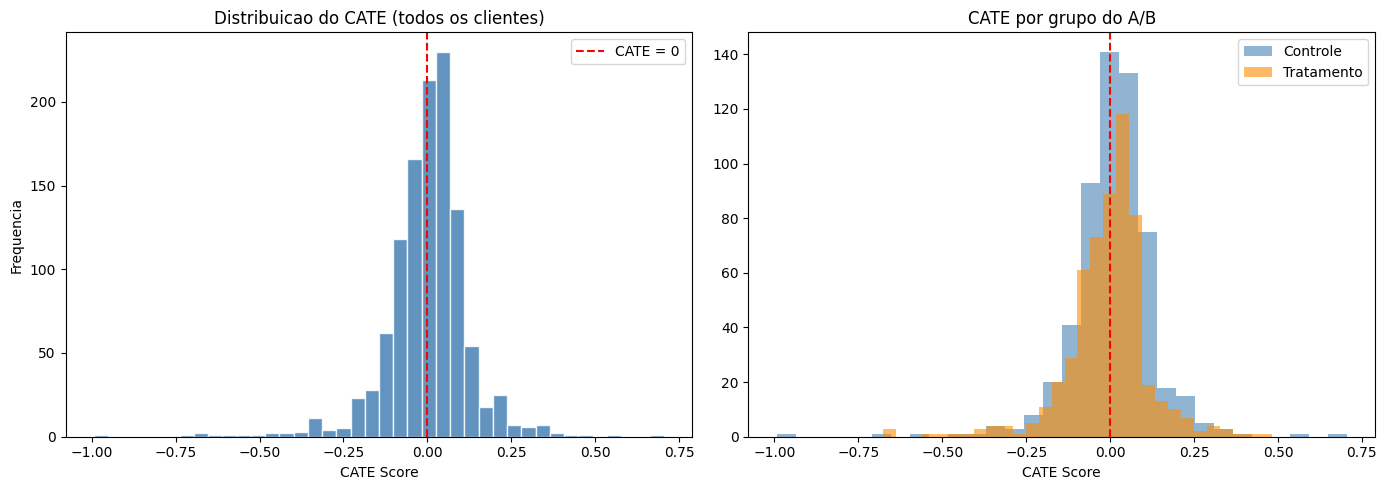

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cate, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='CATE = 0')
axes[0].set_xlabel('CATE Score')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao do CATE (todos os clientes)')
axes[0].legend()

axes[1].hist(df.loc[df['grupo'] == 0, 'cate_score'], bins=30,
             alpha=0.6, label='Controle', color='steelblue')
axes[1].hist(df.loc[df['grupo'] == 1, 'cate_score'], bins=30,
             alpha=0.6, label='Tratamento', color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('CATE Score')
axes[1].set_title('CATE por grupo do A/B')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'uplift_cate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Segmentacao em 4 perfis

**Dois eixos — Opcao A:**
- **Eixo do efeito** (CATE): threshold = 0 (acima = campanha ajuda)
- **Eixo do risco base** (p_control): threshold = mediana de `p_control`

| | Risco base ALTO | Risco base BAIXO |
|---|---|---|
| **CATE > 0** | **Persuadible** — alvo principal | **Sure Thing** — retornaria mesmo sem campanha |
| **CATE <= 0** | **Lost Cause** — nao responde ao tratamento | **Sleeping Dog** — campanha pode prejudicar |

In [10]:
P_CONTROL_MEDIAN = df['p_control'].median()

def classify_profile(row):
    high_cate = row['cate_score'] > CATE_THRESHOLD
    high_risk = row['p_control'] >= P_CONTROL_MEDIAN
    if high_cate and high_risk:
        return 'Persuadible'
    elif high_cate and not high_risk:
        return 'Sure Thing'
    elif not high_cate and high_risk:
        return 'Lost Cause'
    else:
        return 'Sleeping Dog'

df['perfil'] = df.apply(classify_profile, axis=1)

profile_order = ['Persuadible', 'Sure Thing', 'Lost Cause', 'Sleeping Dog']
summary = (
    df.groupby('perfil')
    .agg(
        n=('cate_score', 'count'),
        cate_medio=('cate_score', 'mean'),
        p_control_medio=('p_control', 'mean'),
        p_treatment_medio=('p_treatment', 'mean'),
        churn_real_medio=('churn_real', 'mean'),
    )
    .reindex(profile_order)
    .round(3)
)
print(f'Mediana p_control (threshold risco base): {P_CONTROL_MEDIAN:.4f}')
print()
print(summary)

Mediana p_control (threshold risco base): 0.4890

                n  cate_medio  p_control_medio  p_treatment_medio  \
perfil                                                              
Persuadible   433       0.092            0.569              0.477   
Sure Thing    187       0.045            0.460              0.415   
Lost Cause    134      -0.050            0.532              0.582   
Sleeping Dog  380      -0.106            0.420              0.526   

              churn_real_medio  
perfil                          
Persuadible              0.497  
Sure Thing               0.401  
Lost Cause               0.530  
Sleeping Dog             0.408  


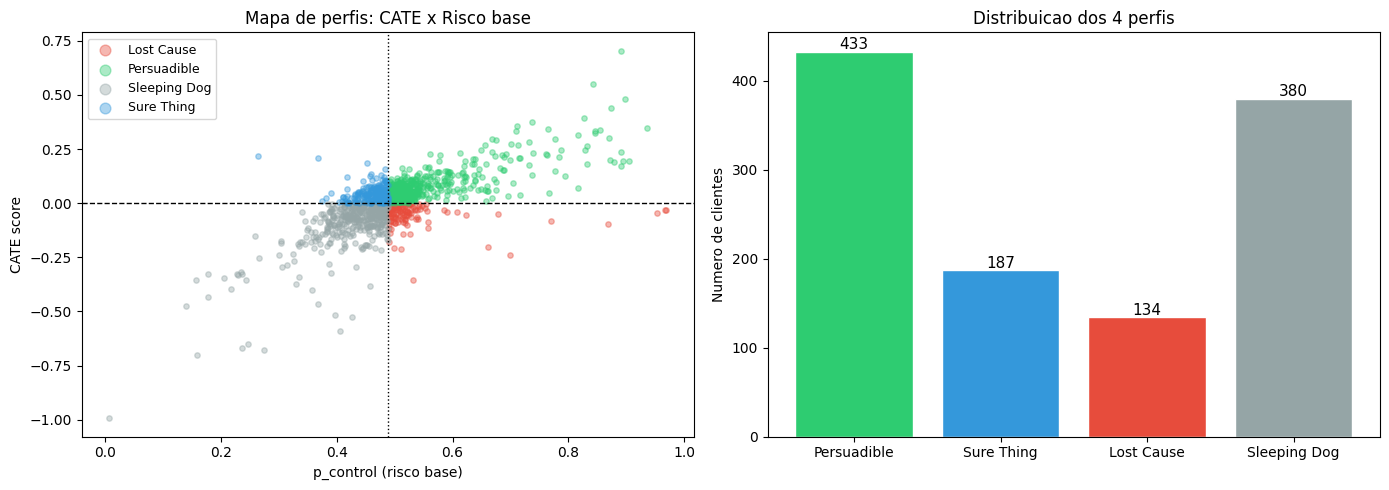

In [11]:
COLORS = {
    'Persuadible': '#2ecc71',
    'Sure Thing':  '#3498db',
    'Lost Cause':  '#e74c3c',
    'Sleeping Dog':'#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for perfil, grp in df.groupby('perfil'):
    axes[0].scatter(grp['p_control'], grp['cate_score'],
                    alpha=0.4, s=15, label=perfil, color=COLORS[perfil])
axes[0].axhline(CATE_THRESHOLD, color='black', linestyle='--', linewidth=1)
axes[0].axvline(P_CONTROL_MEDIAN, color='black', linestyle=':', linewidth=1)
axes[0].set_xlabel('p_control (risco base)')
axes[0].set_ylabel('CATE score')
axes[0].set_title('Mapa de perfis: CATE x Risco base')
axes[0].legend(markerscale=2, fontsize=9)

ns = summary['n'].reindex(profile_order)
bars = axes[1].bar(profile_order, ns,
                   color=[COLORS[p] for p in profile_order], edgecolor='white')
for bar, val in zip(bars, ns):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 3, str(val), ha='center', fontsize=11)
axes[1].set_ylabel('Numero de clientes')
axes[1].set_title('Distribuicao dos 4 perfis')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'uplift_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Qini curve e AUUC

Ordena clientes por `cate_score` e mede o ganho cumulativo de uplift vs seleção aleatória.  
**AUUC > 0:** o modelo gera valor ao priorizar Persuadibles.  
**Nota:** `churn_real` é label histórico — AUUC é indicativo, não definitivo.

In [12]:
def compute_qini(df_eval, cate_col, outcome_col, group_col):
    """Qini para campanha de RETENCAO: u = control_rate - treatment_rate.
    Positivo no topo = campanha reduz churn nos clientes priorizados.
    """
    df_s = df_eval.sort_values(cate_col, ascending=False).reset_index(drop=True)
    n_t_all = (df_s[group_col] == 1).sum()
    n_c_all = (df_s[group_col] == 0).sum()
    # base_rate: efeito medio no conjunto completo (ctrl - trat para retencao)
    base_rate = (
        df_s.loc[df_s[group_col] == 0, outcome_col].sum() / n_c_all
      - df_s.loc[df_s[group_col] == 1, outcome_col].sum() / n_t_all
    )
    qini, baseline = [], []
    for k in range(1, len(df_s) + 1):
        sub = df_s.iloc[:k]
        n_t = (sub[group_col] == 1).sum()
        n_c = (sub[group_col] == 0).sum()
        if n_t == 0 or n_c == 0:
            qini.append(0.0)
        else:
            u = (sub.loc[sub[group_col] == 0, outcome_col].sum() / n_c
               - sub.loc[sub[group_col] == 1, outcome_col].sum() / n_t)
            qini.append(u * k)
        baseline.append(base_rate * k)
    return np.array(qini), np.array(baseline)

# ── AUUC pool inteiro (inclui treino — magnitude inflada por overfitting) ──
qini_curve, random_curve = compute_qini(df, 'cate_score', TARGET, 'grupo')
auuc        = np.trapz(qini_curve)   / len(df)
auuc_random = np.trapz(random_curve) / len(df)
auuc_gain   = auuc - auuc_random

print(f'=== AUUC — Pool inteiro (n={len(df)}) ===')
print(f'AUUC modelo  : {auuc:.4f}')
print(f'AUUC random  : {auuc_random:.4f}')
print(f'Ganho AUUC   : {auuc_gain:.4f}  [{"+melhor" if auuc_gain > 0 else "-pior"} que aleatorio]')

# ── AUUC test-only (avaliacao honesta — sem contaminacao do treino) ────────
df_test_eval = df[df['is_test']].copy()
qini_test, random_test = compute_qini(df_test_eval, 'cate_score', TARGET, 'grupo')
auuc_test        = np.trapz(qini_test)   / len(df_test_eval)
auuc_random_test = np.trapz(random_test) / len(df_test_eval)
auuc_gain_test   = auuc_test - auuc_random_test

print(f'\n=== AUUC — Test only (n={len(df_test_eval)}, avaliacao honesta) ===')
print(f'AUUC modelo  : {auuc_test:.4f}')
print(f'AUUC random  : {auuc_random_test:.4f}')
print(f'Ganho AUUC   : {auuc_gain_test:.4f}  [{"+melhor" if auuc_gain_test > 0 else "-pior"} que aleatorio]')


=== AUUC — Pool inteiro (n=1134) ===
AUUC modelo  : 17.1129
AUUC random  : -14.0000
Ganho AUUC   : 31.1128  [+melhor que aleatorio]

=== AUUC — Test only (n=228, avaliacao honesta) ===
AUUC modelo  : 0.6793
AUUC random  : -2.9999
Ganho AUUC   : 3.6792  [+melhor que aleatorio]


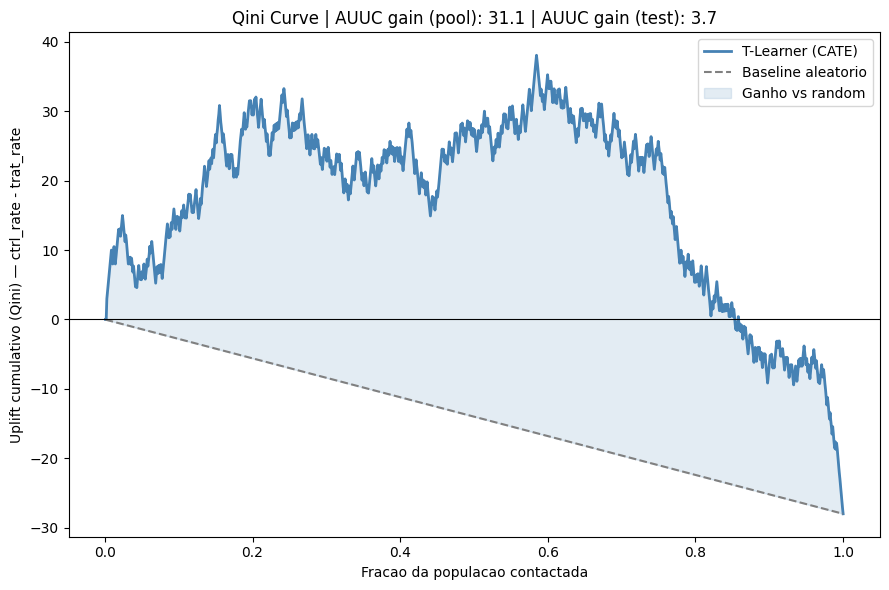

Nota: positivo = campanha reduz churn nos clientes priorizados pelo modelo


In [13]:
x = np.arange(1, len(df) + 1) / len(df)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, qini_curve,  color='steelblue', linewidth=2, label='T-Learner (CATE)')
ax.plot(x, random_curve, color='gray', linewidth=1.5,
        linestyle='--', label='Baseline aleatorio')
ax.fill_between(x, qini_curve, random_curve,
                where=(qini_curve >= random_curve),
                alpha=0.15, color='steelblue', label='Ganho vs random')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Fracao da populacao contactada')
ax.set_ylabel('Uplift cumulativo (Qini) — ctrl_rate - trat_rate')
ax.set_title(
    f'Qini Curve | AUUC gain (pool): {auuc_gain:.1f} | AUUC gain (test): {auuc_gain_test:.1f}'
)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'uplift_qini_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Nota: positivo = campanha reduz churn nos clientes priorizados pelo modelo')


## 10. Analise de negocio — Top Persuadibles

In [14]:
top_k = (
    df[df['perfil'] == 'Persuadible']
    .sort_values('cate_score', ascending=False)
    .head(TOP_K)
)

n_targeted     = len(top_k)
custo_campanha = n_targeted * CUSTO_CONTATO
cate_medio     = top_k['cate_score'].mean()
retencoes_esp  = n_targeted * cate_medio
receita_esp    = retencoes_esp * TICKET_MEDIO * (1 - DESCONTO)
lucro          = receita_esp - custo_campanha
roi            = lucro / custo_campanha if custo_campanha > 0 else 0

print(f'=== Top-{TOP_K} Persuadibles ===')
print(f'CATE medio          : {cate_medio:.3f}')
print(f'Custo da campanha   : R${custo_campanha:,.0f}')
print(f'Retencoes esperadas : {retencoes_esp:.1f}')
print(f'Receita esperada    : R${receita_esp:,.0f}')
print(f'Lucro liquido       : R${lucro:,.0f}')
print(f'ROI direcionado     : {roi:.1%}')
print()
print(f'ROI A/B amplo (1134 clientes)   : 51.7%')
print(f'ROI campanha direcionada (top {TOP_K}): {roi:.1%}')

=== Top-200 Persuadibles ===
CATE medio          : 0.153
Custo da campanha   : R$3,000
Retencoes esperadas : 30.6
Receita esperada    : R$9,646
Lucro liquido       : R$6,646
ROI direcionado     : 221.5%

ROI A/B amplo (1134 clientes)   : 51.7%
ROI campanha direcionada (top 200): 221.5%


## 11. Artefatos e limitacoes

### Nota sobre o modelo
T-Learner implementado com **Logistic Regression** (C=0.5, class_weight='balanced').
XGBoost foi descartado após QA: com n~450/grupo e 21 features, o gap de overfitting foi de
0.201–0.303, inviabilizando o CATE individual. LR tem variância estruturalmente menor para
esse tamanho de amostra.

### Limitacoes
1. `churn_real` e label historico — AUUC mede consistencia com dados passados, nao eficacia futura
2. T-Learner com ~450 amostras/grupo — sinal fraco para CATE individual; interpretacao
   deve ser populacional, nao client-level
3. Lift de 30% (hipotese do A/B) permanece nao validado em producao
4. Sleeping Dogs identificados com label historico — comportamento pode diferir em producao
5. AUC dos modelos LR proximos de 0.5 indicam que as features comportamentais historicas
   nao separam bem os grupos dentro do pool de risco — efeito causal real pode ser
   heterogeneo em dimensoes nao observadas neste dataset


In [15]:
uplift_scores = df[['cate_score', 'perfil']].copy()
uplift_scores.to_parquet(OUTPUT_PATH)
print(f'Salvo: {OUTPUT_PATH}  | shape: {uplift_scores.shape}')

os.makedirs('models/uplift', exist_ok=True)
joblib.dump(model_c, 'models/uplift/lr_control.pkl')
joblib.dump(model_t, 'models/uplift/lr_treatment.pkl')
print('Salvo: models/uplift/lr_control.pkl')
print('Salvo: models/uplift/lr_treatment.pkl')

print()
print('Distribuicao final dos perfis:')
print(df['perfil'].value_counts())


Salvo: data/processed/uplift_scores.parquet  | shape: (1134, 2)
Salvo: models/uplift/lr_control.pkl
Salvo: models/uplift/lr_treatment.pkl

Distribuicao final dos perfis:
perfil
Persuadible     433
Sleeping Dog    380
Sure Thing      187
Lost Cause      134
Name: count, dtype: int64
